# Examining Rookies in the NFL and their Fantasy Potential
Author: Alexander Hamilton

## Why Analyze Rookie NFL Players for Fantasy Football?

Analyzing the fantasy season performance of rookie NFL players can be incredibly beneficial for fantasy football enthusiasts and managers. Rookies often present unique opportunities and challenges:

*   **Untapped Potential:** Many rookies enter the league with high ceilings but unknown immediate impact. Identifying those who can quickly adapt and produce and what their common qualities are can give a significant edge.
*   **Value in Drafts:** Savvy fantasy managers can draft high-impact rookies at a lower cost than established veterans, leading to excellent return on investment.
*   **Dynamic Roster Building:** Rookies can fill critical gaps in a fantasy roster, especially in dynasty leagues where long-term value is key.
*   **Predictive Insights:** Understanding which rookie profiles (e.g., draft capital, college production, athletic traits, team situation) tend to translate best to fantasy success can inform future draft strategies.

This analysis aims to uncover patterns and insights from the 2025 rookie class to help fantasy managers make informed decisions and gain a competitive advantage.

# Analyzing the Fantasy League Value of Rookies in the NFL

We will be taking the 2025 NFL Fantasy season and only looking at the top percentage of all offensive skill position players that an average fantasy league would end up drafting. So in this study we will not look at special teams, defense, or offensive line as they usually have no effect on typical fantasy leagues, especially first year players from these groups.

In [306]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import sklearn

# Load Fantasy Player Data

In [307]:
fantasy_qb = pd.read_csv('fantasy/Fantasy_QB.csv')
fantasy_rb = pd.read_csv('fantasy/Fantasy_RB.csv')
fantasy_wr = pd.read_csv('fantasy/Fantasy_WR.csv')
fantasy_te = pd.read_csv('fantasy/Fantasy_TE.csv')

# Clean up data by only taking top performers

We choose the top of each position according to fantasy standards to cut down the data. So a standard 10-12 man PPR league would have 2 quarterbacks, 3 runningbacks, 4 wide recievers, and 2 tight ends drafted, at least, for each team.

We then also cut down the columns of each table and only take the players rank (based on fantasy points), their name, and their actual fantasy point total.

In [308]:
#clean data by only keeping top fantasy qbs (approx 2 per team in a 12-team league)
fantasy_qbs = fantasy_qb.sort_values(by='FPTS', ascending=False).head(24)
fantasy_qbs = fantasy_qbs[['Rank', 'Player', 'FPTS']].copy()

#clean data by only keeping top fantasy rbs (approx 3 per team in a 12-team league)
fantasy_rbs = fantasy_rb.sort_values(by='FPTS', ascending=False).head(36)
fantasy_rbs = fantasy_rbs[['Rank', 'Player', 'FPTS']].copy()

#clean data by only keeping top fantasy receivers (approx 4 per team in a 12-team league)
fantasy_wrs = fantasy_wr.sort_values(by='FPTS', ascending=False).head(48)
fantasy_wrs = fantasy_wrs[['Rank', 'Player', 'FPTS']].copy()

#clean data by only keeping top fantasy tes (approx 2 per team in a 12-team league)
fantasy_tes = fantasy_te.sort_values(by='FPTS', ascending=False).head(24)
fantasy_tes = fantasy_tes[['Rank', 'Player', 'FPTS']].copy()

In [309]:
# clip off the team name at the end of the player column
def remove_suffix_after_last_space(player_name):
    if isinstance(player_name, str):
        # rsplit will split the string from the right, at most once
        # e.g., "Josh Allen (BUF)".rsplit(' ', 1) -> ['Josh Allen', '(BUF)']
        # If the name is already processed to 'Josh Allen (B', it would be:
        # 'Josh Allen (B'.rsplit(' ', 1) -> ['Josh Allen', '(B']
        parts = player_name.rsplit(' ', 1)
        if len(parts) > 1:
            return " ".join(parts[:-1])
        else:
            return player_name # No space to split from, or only one word
    return player_name # Return as is if not a string

fantasy_qbs['Player'] = fantasy_qbs['Player'].apply(remove_suffix_after_last_space)

fantasy_rbs['Player'] = fantasy_rbs['Player'].apply(remove_suffix_after_last_space)

fantasy_wrs['Player'] = fantasy_wrs['Player'].apply(remove_suffix_after_last_space)

fantasy_tes['Player'] = fantasy_tes['Player'].apply(remove_suffix_after_last_space)

#display top 5 performer of each position neatly
def create_html_table(df, title):
    html = f'<h4>{title}</h4>'
    html += df.head(5).to_html()
    return html

dfs_to_display = [
    ('Quarterbacks', fantasy_qbs),
    ('Running Backs', fantasy_rbs),
    ('Wide Receivers', fantasy_wrs),
    ('Tight Ends', fantasy_tes)
]

html_str = '<h1>Top 5 Players at Each Position</h1><table style="width:100%; border-collapse: collapse;">'
for i in range(0, len(dfs_to_display), 2):
    html_str += '<tr>'
    for j in range(2):
        if i + j < len(dfs_to_display):
            title, df = dfs_to_display[i + j]
            html_str += f'<td style="width:50%; padding: 10px; vertical-align: top;">{create_html_table(df, title)}</td>'
        else:
            html_str += '<td style="width:50%;"></td>' # Empty cell for alignment
    html_str += '</tr>'
html_str += '</table>'

display(HTML(html_str))

,Rank,Player,FPTS
0,1.0,Josh Allen,374.5
1,2.0,Drake Maye,358.9
2,3.0,Matthew Stafford,358.3
3,4.0,Trevor Lawrence,350.1
4,5.0,Dak Prescott,323.8
,Rank,Player,FPTS
0,1.0,Jonathan Taylor,316.3
1,2.0,Christian McCaffrey,314.6
2,3.0,Bijan Robinson,291.8
3,4.0,Jahmyr Gibbs,289.9


# Load 2025 Rookie Data

Now we will grab the rookie draft class of 2025 from Pro Football Reference. We will grab what round, pick, and team they were drafted to, along with player name, position, college, and 2025 Regualr Season NFL Fantasy Points.

In [310]:
draft2025 = pd.read_csv('rookies/2025.csv')

In [311]:
fantasy_qb_names = fantasy_qbs['Player'].tolist()
matching_qbs = draft2025[draft2025['Player'].isin(fantasy_qb_names)]
matching_qbs = matching_qbs[['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'College/Univ']].copy()
# Add FPTS column to matching_qbs
matching_qbs = pd.merge(matching_qbs, fantasy_qbs[['Player', 'FPTS']], on='Player', how='left')

fantasy_wrs_names = fantasy_wrs['Player'].tolist()
matching_wrs = draft2025[draft2025['Player'].isin(fantasy_wrs_names)]
matching_wrs = matching_wrs[['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'College/Univ']].copy()
# Add FPTS column to matching_wrs
matching_wrs = pd.merge(matching_wrs, fantasy_wrs[['Player', 'FPTS']], on='Player', how='left')

fantasy_rbs_names = fantasy_rbs['Player'].tolist()
matching_rbs = draft2025[draft2025['Player'].isin(fantasy_rbs_names)]
matching_rbs = matching_rbs[['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'College/Univ']].copy()
# Add FPTS column to matching_rbs
matching_rbs = pd.merge(matching_rbs, fantasy_rbs[['Player', 'FPTS']], on='Player', how='left')

fantasy_tes_names = fantasy_tes['Player'].tolist()
matching_tes = draft2025[draft2025['Player'].isin(fantasy_tes_names)]
matching_tes = matching_tes[['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'College/Univ']].copy()
# Add FPTS column to matching_tes
matching_tes = pd.merge(matching_tes, fantasy_tes[['Player', 'FPTS']], on='Player', how='left')

def create_html_table(df, title):
    html = f'<h4>{title}</h4>'
    html += df.to_html()
    return html

# Display top rookies neatly
dfs_to_display = [
    ('Quarterbacks', matching_qbs),
    ('Running Backs', matching_rbs),
    ('Wide Receivers', matching_wrs),
    ('Tight Ends', matching_tes)
]

html_str = '<h1>Rookies Likely to be Drafted in Fantasy</h1><table style="width:100%; border-collapse: collapse;">'
for i in range(0, len(dfs_to_display), 2):
    html_str += '<tr>'
    for j in range(2):
        if i + j < len(dfs_to_display):
            title, df = dfs_to_display[i + j]
            html_str += f'<td style="width:50%; padding: 10px; vertical-align: top;">{create_html_table(df, title)}</td>'
        else:
            html_str += '<td style="width:50%;"></td>' # Empty cell for alignment
    html_str += '</tr>'
html_str += '</table>'

display(HTML(html_str))

,Rnd,Pick,Tm,Player,Pos,College/Univ,FPTS
0,1,1,TEN,Cam Ward,QB,Miami (FL),193.7
1,1,25,NYG,Jaxson Dart,QB,Mississippi,246.5
,Rnd,Pick,Tm,Player,Pos,College/Univ,FPTS
0,1,6,LVR,Ashton Jeanty,RB,Boise St.,190.1
1,2,36,CLE,Quinshon Judkins,RB,Ohio St.,143.8
2,2,38,NWE,TreVeyon Henderson,RB,Ohio St.,171.2
3,2,60,DEN,RJ Harvey,RB,Central Florida,159.6
4,4,116,HOU,Woody Marks,RB,USC,127.1
5,7,233,CHI,Kyle Monangai,RB,Rutgers,128.7
6,7,245,WAS,Jacory Croskey-Merritt,RB,Arizona,131.3


# Graph based on the draft success by Team

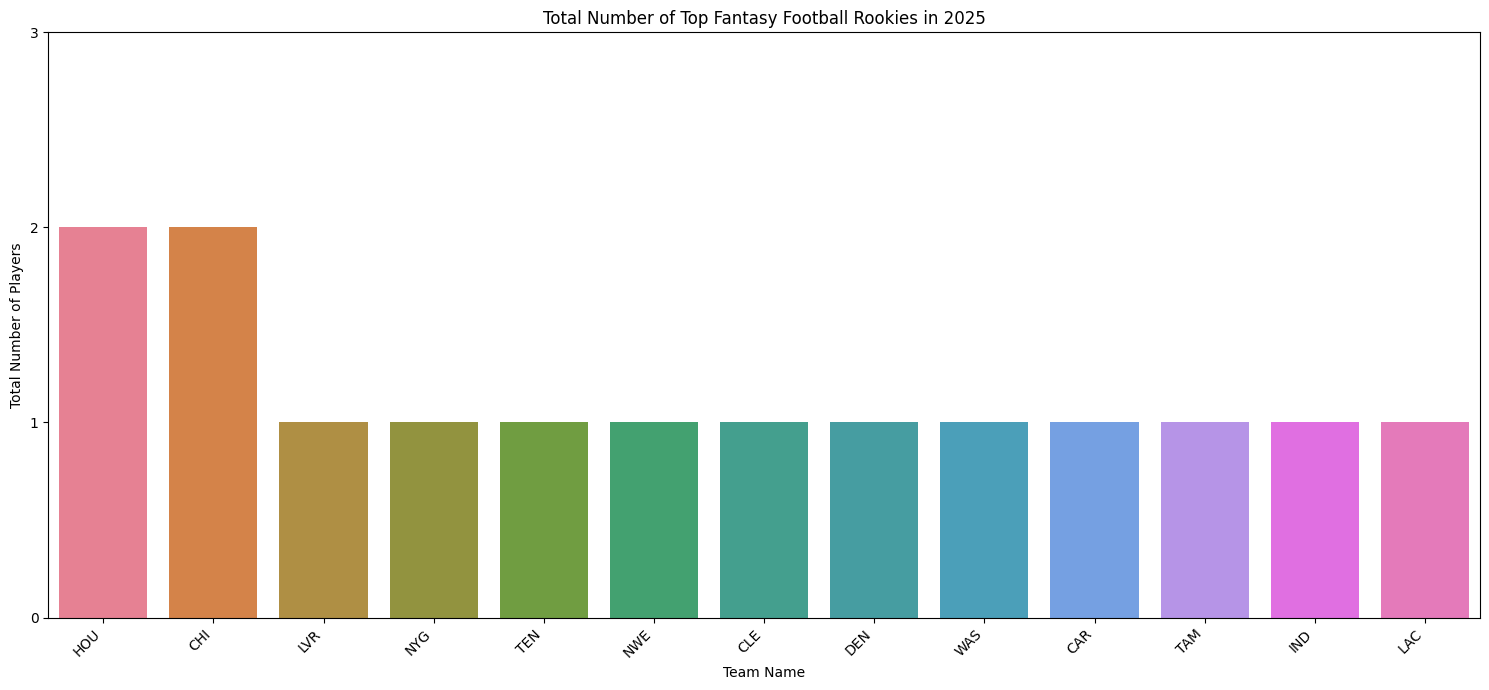

In [322]:
combined_matching_players = pd.concat([
    matching_qbs[['Tm', 'Player']],
    matching_rbs[['Tm', 'Player']],
    matching_wrs[['Tm', 'Player']],
    matching_tes[['Tm', 'Player']]
])

team_counts_combined = combined_matching_players['Tm'].value_counts()

# Filter to include only teams with 2 or more rookies
team_counts_filtered = team_counts_combined[team_counts_combined >= 0]

if not team_counts_filtered.empty:
    plt.figure(figsize=(15, 7))
    sns.barplot(x=team_counts_filtered.index, y=team_counts_filtered.values, hue=team_counts_filtered.index, legend='auto')
    plt.title('Total Number of Top Fantasy Football Rookies in 2025')
    plt.xlabel('Team Name')
    plt.ylabel('Total Number of Players')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(np.arange(0, team_counts_filtered.values.max() + 2, 1)) # Set y-axis to whole numbers
    plt.tight_layout()
    plt.show()
else:
    print("No combined players found to plot with 2 or more rookies per team.")

# Graphs based on the number of players of the college and position

Here we look for similarities based on where each player went to college along with the bar graph of how many rookies were top fantasy options based on their respective position.

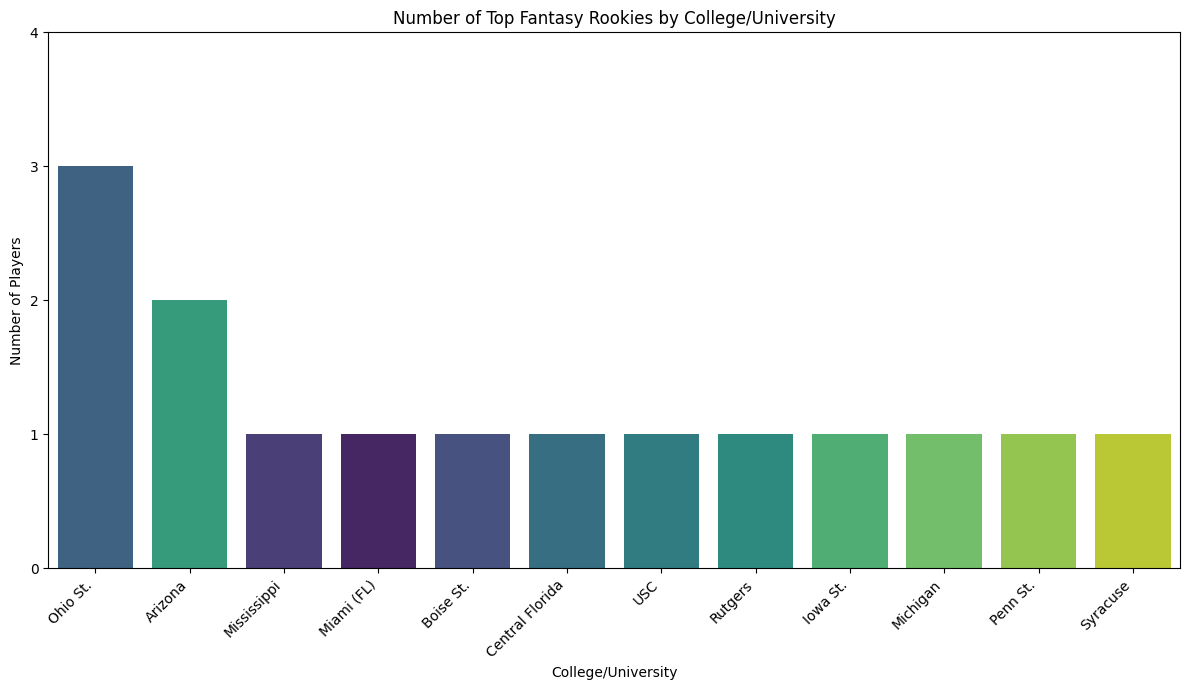

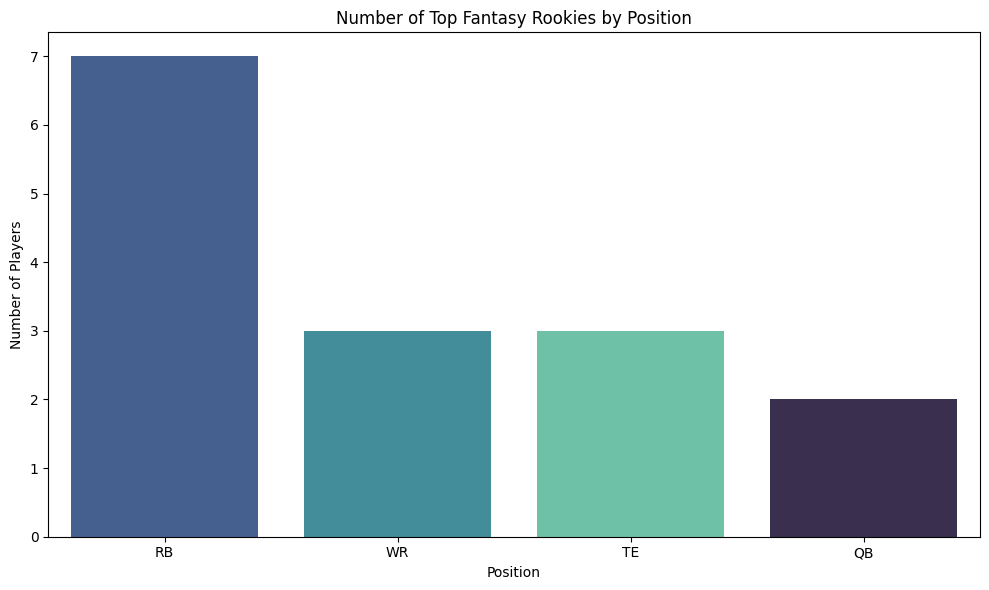

In [327]:
# Combine all matching players into a single DataFrame
all_matching_players = pd.concat([
    matching_qbs[['Player', 'Pos', 'College/Univ']],
    matching_rbs[['Player', 'Pos', 'College/Univ']],
    matching_wrs[['Player', 'Pos', 'College/Univ']],
    matching_tes[['Player', 'Pos', 'College/Univ']]
])

# Graph 1: Number of players by School
plt.figure(figsize=(12, 7))
sns.countplot(data=all_matching_players, x='College/Univ', hue='College/Univ', palette='viridis', order=all_matching_players['College/Univ'].value_counts().index, legend=False)
plt.title('Number of Top Fantasy Rookies by College/University')
plt.xlabel('College/University')
plt.ylabel('Number of Players')
plt.xticks(rotation=45, ha='right')
# Set y-axis to whole numbers
plt.yticks(np.arange(0, all_matching_players['College/Univ'].value_counts().max() + 2, 1))
plt.tight_layout()
plt.show()

# Graph 2: Number of players by Position
plt.figure(figsize=(10, 6))
sns.countplot(data=all_matching_players, x='Pos', hue='Pos', palette='mako', order=all_matching_players['Pos'].value_counts().index, legend=False)
plt.title('Number of Top Fantasy Rookies by Position')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

#### Interpretation of College and Position Graphs

**Number of Top Fantasy Rookies by College/University:**
This bar chart displays the colleges that have produced the most top fantasy-relevant rookies in the 2025 NFL Draft class. Each bar represents a college, and its height indicates the total number of players from that institution who made it into the top fantasy tiers for their respective positions (QB, RB, WR, TE).

*   **Purpose:** This graph helps identify 'talent factories' in college football that consistently produce high-impact NFL players who quickly become fantasy assets. A college with a tall bar suggests strong scouting, player development, or a system that prepares players well for immediate NFL success.
*   **Interpretation:** For example, if 'Ohio State' has the tallest bar, it implies that players drafted from Ohio State are more likely to be valuable fantasy picks in their rookie year compared to players from other schools. This insight can be crucial for fantasy managers looking for reliable rookie talent.

**Number of Top Fantasy Rookies by Position:**
This bar chart illustrates the distribution of top fantasy rookies across different offensive skill positions. Each bar corresponds to a position (Quarterback, Running Back, Wide Receiver, Tight End), and its height indicates how many top fantasy rookies belong to that position.

*   **Purpose:** This graph highlights which positions tend to yield the most fantasy-relevant rookies. It can reveal if certain positions are easier for rookies to make an immediate impact in fantasy leagues, or if specific positions are more saturated with high-performing rookies in a given draft class.
*   **Interpretation:** If the 'RB' (Running Back) bar is significantly taller than others, it suggests that rookie running backs are more likely to achieve top fantasy status. This information can guide fantasy draft strategies, indicating which positions might offer better 'rookie value' or present higher risk/reward scenarios.

# Conclusion
### Analysis of Top Fantasy Rookies (2025)

Based on the analysis of the graphs, several key commonalities emerge regarding the top fantasy rookies in 2025:

*   **Position Dominance:** The 'Number of Top Fantasy Rookies by Position' graph clearly shows that **Running Backs (RB)** are a prominent position among the top fantasy performers. This suggests a significant impact from rookie running backs in fantasy leagues.
*   **College Hotbed:** From the 'Number of Top Fantasy Rookies by College/University' graph, **Ohio State** stands out as a strong producer of top-tier talent. This indicates that players from this university frequently make an immediate fantasy impact in their rookie year.
*   **Team Success in Drafting:** Looking at the 'Total Number of Top Fantasy Football Rookies in 2025 (Teams with 2+ Players)' and the individual position graphs, teams like **Houston (HOU)** and **Chicago (CHI)** have successfully drafted multiple high-impact rookies across different positions. This implies strong scouting and player development for these franchises, leading to multiple fantasy-relevant rookies in a single draft class.

So, when drafting rookies in your fantasy league you can count on 3 things: running backs are best value for rookies, rookies from Ohio State tend to do well, and teams looking to make the playoffs following the draft (Chicago and Houston for example) provide the best space for rookies to score fantasy points.

## Citations:
"NFL Fantasy Football Leaders." FantasyData, 12 Apr. 2024, https://fantasydata.com/nfl/fantasy-football-leaders?scope=season&sp=2025_REG&position=qb&scoring=fpts_ppr&order_by=fpts_ppr&sort_dir=desc.

"2025 NFL Draft." Pro-Football-Reference.com, Sports Reference LLC, 12 Apr. 2024, https://www.pro-football-reference.com/years/2025/draft.htm.